In [2]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk
from rprint import rprint

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


3.1 ModelCallLimitMiddleware中间件
限制模型调用次数，避免无限循环，控制调用成本。
举例1：整个会话限制-优雅退出

In [3]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing import List

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),  # Required for thread limiting
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=2,  # 每个线程最多2次模型调用
            # run_limit=5,   # 每次运行最多5次
            exit_behavior="end",  # 达到限制后退出
        ),
    ],
)


def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
                                      AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()


config = {"configurable": {"thread_id": "1"}}

response_first = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)
print("=" * 30, "> first <", "=" * 30)

pretty_iterate_msg(response_first["messages"])
response_second = agent.invoke({
    "messages": [HumanMessage("你是谁？")]},
    config=config
)
print("=" * 30, "> second <", "=" * 30)
pretty_iterate_msg(response_second["messages"])
response_third = agent.invoke({
    "messages": [HumanMessage("你能帮我做什么？")]},
    config=config
)
print("=" * 30, "> third <", "=" * 30)

pretty_iterate_msg(response_third["messages"])

============================== > first < ==============================
================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！很高兴见到你！😊 有什么我可以帮助你的吗？无论是聊天、解答问题，还是需要一些建议，我都在这里！
============================== > second < ==============================
================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！很高兴见到你！😊 有什么我可以帮助你的吗？无论是聊天、解答问题，还是需要一些建议，我都在这里！
================================ Human Message =================================

你是谁？
================================== Ai Message ==================================

你好呀！我是 **DeepSeek**，一个由深度求索公司创造的AI助手！😊

简单介绍一下自己：
- **身份**：我是纯文本AI模型，擅长理解和生成文字内容
- **能力**：可以回答问题、写作、编程、翻译、分析数据等等
- **特点**：免费使用，支持上传文件（图片、PDF、Word等），还能联网搜索（需手动开启）
- **版本**：我是DeepSeek最新版模型，知识截止于2025年5月

虽然我不能识别图片内容，但可以读取图片、文档里的文字信息来帮你处理问题。而且我支持超长上下文（1M

举例2：整个会话限制-抛异常

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),  # Required for thread limiting
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=2,
            run_limit=1,
            exit_behavior="error",
        ),
    ],
)


def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
                                      AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()


config = {"configurable": {"thread_id": "1"}}
response_first = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)
print("=" * 30, "> first <", "=" * 30)
pretty_iterate_msg(response_first["messages"])
response_second = agent.invoke({
    "messages": [HumanMessage("你是谁？")]},
    config=config
)
print("=" * 30, "> second <", "=" * 30)
pretty_iterate_msg(response_second["messages"])
response_third = agent.invoke({
    "messages": [HumanMessage("你能帮我做什么？")]},
    config=config
)
print("=" * 30, "> third <", "=" * 30)
pretty_iterate_msg(response_third["messages"])

============================== > first < ==============================
================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！很高兴见到你！😊 有什么我可以帮你的吗？无论是聊天、解答问题、还是提供信息，我都很乐意帮忙！
============================== > second < ==============================
================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！很高兴见到你！😊 有什么我可以帮你的吗？无论是聊天、解答问题、还是提供信息，我都很乐意帮忙！
================================ Human Message =================================

你是谁？
================================== Ai Message ==================================

你好！我是**DeepSeek**，由深度求索公司创造的AI助手！😊

我是一个纯文本模型，擅长回答问题、提供信息、帮助解决问题。虽然我不支持多模态识别（比如直接“看”图片），但你可以上传图像、PDF、Word、Excel等文件，我会从中读取文字信息来帮助你。

我的一些特点包括：
- **免费使用**，没有收费计划
- **超长上下文**（1M tokens），可以一次性处理像《三体》三部曲那么大体量的内容
- **支持联网搜索**（需要手动开启）
- **支持语音输入**（App端）

我的知识

ModelCallLimitExceededError: Model call limits exceeded: thread limit (2/2)

举例3：单次调用限制-优雅退出
需要fake-server重复触发工具调用，代码如下

注意：服务端代码逻辑是80%概率输出非法响应，所以不一定会导致单次请求的工具调用超过限制，尝
试几次即可看到效果。
客户端代码

In [21]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_deepseek import ChatDeepSeek
from pydantic import BaseModel, Field, SecretStr
from typing import List, Union
from rich import print as rprint
from dotenv import load_dotenv

load_dotenv()
model = ChatDeepSeek(
    model="any",
    api_base="http://localhost:8889",
    api_key=SecretStr("<KEY>")
)


class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")


class EventInfo(BaseModel):
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")


agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),  # Required for thread limiting
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            # thread_limit=2,
            run_limit=3,
            exit_behavior="end",
        ),
    ],
    response_format=Union[ContactInfo, EventInfo]
)
config = {"configurable": {"thread_id": "1"}}
response = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)
for msg in response["messages"]:
    rprint(msg)


HumanMessage(content='你好', additional_kwargs={}, response_metadata={}, id='f29c30f7-aa66-4312-b3a9-a7814a27067d')

AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 1,
            'prompt_tokens': 1,
            'total_tokens': 2,
            'completion_tokens_details': None,
            'prompt_tokens_details': None
        },
        'model_provider': 'deepseek',
        'model_name': 'any',
        'system_fingerprint': None,
        'id': 'chatcmpl-test',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019f6e0f-9bf4-70f3-bcde-59cac3a0dfc8-0',
    tool_calls=[
        {
            'name': 'ContactInfo',
            'args': {'name': '康师傅', 'email': 'songhongkang@atguigu.cn', 'phone': '12345678912'},
            'id': 'call_1',
            'type': 'tool_call'
        },
        {
            'name': 'EventInfo',
            'args': {'event_name': '问数项目启动会', 'date': '2026-03-27'},
            'id': 'call_2',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 1,
        'output_tokens': 1,
        'total_tokens': 2,
        'input_token_details': {},
        'output_token_details': {}
    }
)

ToolMessage(
    content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one
is expected.\n Please fix your mistakes.',
    name='ContactInfo',
    id='1383f2a4-d7e9-40c4-b3d0-2d5f55196ead',
    tool_call_id='call_1'
)

ToolMessage(
    content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one
is expected.\n Please fix your mistakes.',
    name='EventInfo',
    id='1b9b7124-8929-4ce6-9069-ce44c9cd5faa',
    tool_call_id='call_2'
)

AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 1,
            'prompt_tokens': 1,
            'total_tokens': 2,
            'completion_tokens_details': None,
            'prompt_tokens_details': None
        },
        'model_provider': 'deepseek',
        'model_name': 'any',
        'system_fingerprint': None,
        'id': 'chatcmpl-test',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019f6e0f-c9c6-7b21-bf20-cac9318fb330-0',
    tool_calls=[
        {
            'name': 'ContactInfo',
            'args': {'name': '康师傅', 'email': 'songhongkang@atguigu.cn', 'phone': '12345678912'},
            'id': 'call_1',
            'type': 'tool_call'
        },
        {
            'name': 'EventInfo',
            'args': {'event_name': '问数项目启动会', 'date': '2026-03-27'},
            'id': 'call_2',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 1,
        'output_tokens': 1,
        'total_tokens': 2,
        'input_token_details': {},
        'output_token_details': {}
    }
)

...

ToolMessage(
    content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one
is expected.\n Please fix your mistakes.',
    name='EventInfo',
    id='5509d4d9-5069-47d1-8b18-9f422aba5c45',
    tool_call_id='call_2'
)

AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 1,
            'prompt_tokens': 1,
            'total_tokens': 2,
            'completion_tokens_details': None,
            'prompt_tokens_details': None
        },
        'model_provider': 'deepseek',
        'model_name': 'any',
        'system_fingerprint': None,
        'id': 'chatcmpl-test',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019f6e10-1ce3-7da0-abe9-413d01f10047-0',
    tool_calls=[
        {
            'name': 'ContactInfo',
            'args': {'name': '康师傅', 'email': 'songhongkang@atguigu.cn', 'phone': '12345678912'},
            'id': 'call_1',
            'type': 'tool_call'
        },
        {
            'name': 'EventInfo',
            'args': {'event_name': '问数项目启动会', 'date': '2026-03-27'},
            'id': 'call_2',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 1,
        'output_tokens': 1,
        'total_tokens': 2,
        'input_token_details': {},
        'output_token_details': {}
    }
)

ToolMessage(
    content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one
is expected.\n Please fix your mistakes.',
    name='ContactInfo',
    id='66bf9b68-45a3-49f2-97c9-cdec27d9f0f1',
    tool_call_id='call_1'
)

ToolMessage(
    content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one
is expected.\n Please fix your mistakes.',
    name='EventInfo',
    id='fc497368-790f-41fa-9eb1-bba9c920627b',
    tool_call_id='call_2'
)

AIMessage(
    content='Model call limits exceeded: run limit (3/3)',
    additional_kwargs={},
    response_metadata={},
    id='f75962bd-31e4-4b4f-9c28-2902e4f2a68f',
    tool_calls=[],
    invalid_tool_calls=[]
)

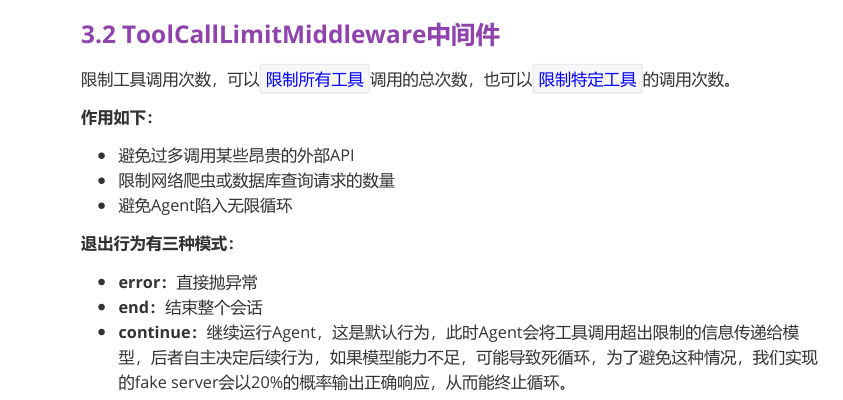

举例1：整个会话限制-优雅结束

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_deepseek import ChatDeepSeek
from pydantic import BaseModel, Field, SecretStr
from typing import List, Union
from dotenv import load_dotenv

load_dotenv(override=True)
model = ChatDeepSeek(
    model="any",
    api_base="http://localhost:8889",
    api_key=SecretStr("<KEY>")
)


class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")


class EventInfo(BaseModel):
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")


agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),  # Required for thread limiting
    tools=[],
    middleware=[
        ToolCallLimitMiddleware(
            # thread_limit=2,  # 每个线程最多2次工具调用
            run_limit=2,
            # 每次运行最多2次
            exit_behavior="end",
        ),
    ],
    response_format=Union[ContactInfo, EventInfo]
)


def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
                                      AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()


config = {"configurable": {"thread_id": "1"}}
response = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)
pretty_iterate_msg(response["messages"])

================================ Human Message =================================

你好
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: call_1
  Args:
    name: 康师傅
    email: songhongkang@atguigu.cn
    phone: 12345678912
  EventInfo (call_2)
 Call ID: call_2
  Args:
    event_name: 问数项目启动会
    date: 2026-03-27
================================= Tool Message =================================
Name: ContactInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================= Tool Message =================================
Name: EventInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: c

案例3：单次调用限制-继续运行

In [25]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_deepseek import ChatDeepSeek
from pydantic import BaseModel, Field, SecretStr
from typing import List, Union
from dotenv import load_dotenv

load_dotenv(override=True)

model = ChatDeepSeek(
    model="any",
    api_base="http://localhost:8889",
    api_key=SecretStr("<KEY>")
)


class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")


class EventInfo(BaseModel):
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")


agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),  # Required for thread limiting
    tools=[],
    middleware=[
        ToolCallLimitMiddleware(
            # thread_limit=2,
            run_limit=2,
            exit_behavior="continue",
        ),
    ],
    response_format=Union[ContactInfo, EventInfo]
)


def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
                                      AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()


config = {"configurable": {"thread_id": "1"}}
response = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)
pretty_iterate_msg(response["messages"])

================================ Human Message =================================

你好
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: call_1
  Args:
    name: 康师傅
    email: songhongkang@atguigu.cn
    phone: 12345678912
  EventInfo (call_2)
 Call ID: call_2
  Args:
    event_name: 问数项目启动会
    date: 2026-03-27
================================= Tool Message =================================
Name: ContactInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================= Tool Message =================================
Name: EventInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: c

ModelFallbackMiddleware中间件
用于故障转移，当主模型无法访问时，启用备用模型。

In [34]:
from langchain.agents.middleware import ModelFallbackMiddleware
from langchain.chat_models import init_chat_model

# 定义主模型和备用模型
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)
fallback = ModelFallbackMiddleware(model)
agent = create_agent(
    model="deepseek:mode",
    tools=[],
    middleware=[fallback],
)

response = agent.invoke({
    "messages": [HumanMessage("你是谁？")]
})
pretty_iterate_msg(response["messages"])

last_msg = response["messages"][-1]
print(last_msg)
print('=' * 30, '-> model_name <-', '=' * 30)
print(last_msg.response_metadata.get("model_name"))

================================ Human Message =================================

你是谁？
================================== Ai Message ==================================

嗨！我是DeepSeek，由深度求索公司创造的AI助手！😊

我是一个纯文本模型，擅长回答各种问题、进行对话交流、帮助你处理文字任务。我有以下特点：

✨ **完全免费** - 没有任何收费计划
📚 **超大上下文** - 1M token容量，可以一次性处理像《三体》三部曲那样的长篇内容
📎 **文件处理** - 支持上传图片、PDF、Word、Excel、PPT等文件，从中读取文字信息
🌐 **联网搜索** - 需要手动开启，获取最新信息
🎙️ **语音输入** - App端支持语音交互

我的知识截止于2025年5月，会尽力用热情、细腻的方式帮助你解决问题。有什么我可以帮到你的吗？无论是学习、工作还是日常疑问，尽管问我！💪
content='嗨！我是DeepSeek，由深度求索公司创造的AI助手！😊\n\n我是一个纯文本模型，擅长回答各种问题、进行对话交流、帮助你处理文字任务。我有以下特点：\n\n✨ **完全免费** - 没有任何收费计划\n📚 **超大上下文** - 1M token容量，可以一次性处理像《三体》三部曲那样的长篇内容\n📎 **文件处理** - 支持上传图片、PDF、Word、Excel、PPT等文件，从中读取文字信息\n🌐 **联网搜索** - 需要手动开启，获取最新信息\n🎙️ **语音输入** - App端支持语音交互\n\n我的知识截止于2025年5月，会尽力用热情、细腻的方式帮助你解决问题。有什么我可以帮到你的吗？无论是学习、工作还是日常疑问，尽管问我！💪' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 177, 'prompt_tokens': 6, 'total_tokens': 183, 'completion_tokens_details': None, 

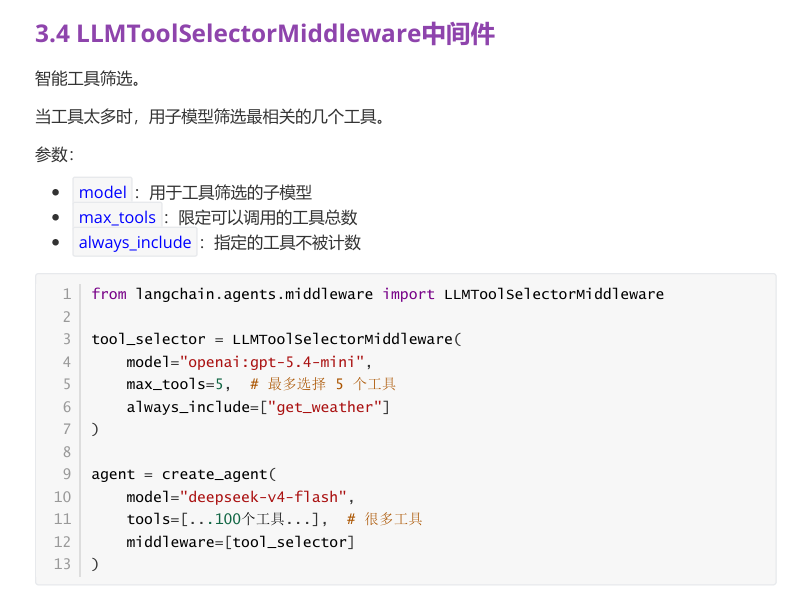

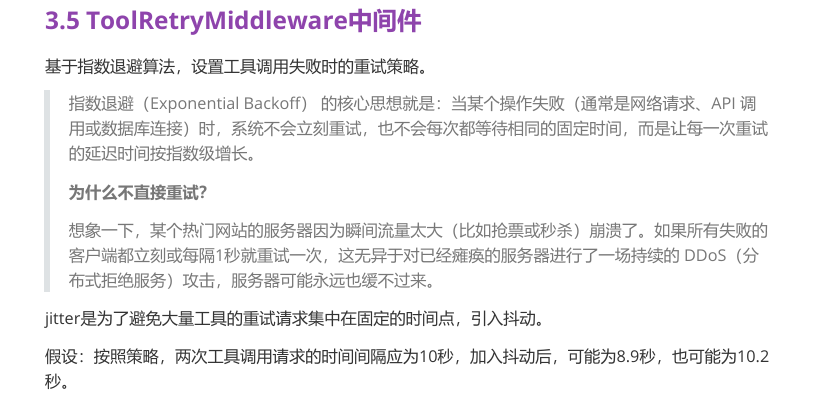

举例1：带抖动

In [35]:
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain.agents.middleware import ToolRetryMiddleware
from langchain.messages import HumanMessage
import datetime


def write_times(s):
    """将每次工具调用的时间戳和间隔写入本地文件，方便观察退避策略"""
    with open("call_times_with_jitter.txt", "a", encoding="utf-8") as f:
        f.write(s + "\n")


count = 1
start_time = None


@tool
def get_weather(city: str):
    """查询指定城市天气"""
    global count
    global start_time
    interval = 0
    current_time = datetime.datetime.now()
    if not start_time:
        interval = 0
    else:
        # 计算当前调用与上一次调用之间的时间差（秒）
        interval = (current_time - start_time).total_seconds()
    start_time = current_time
    res_str = f"第 {count} 次调用，当前时间： {start_time}, 和上次调用间隔 {interval} 秒"
    count += 1
    # 记录日志
    write_times(res_str)
    # 故意抛出 TimeoutError，以此触发中间件的重试机制
    raise TimeoutError("Not Implemented")


agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        # ToolRetryMiddleware 用于捕获工具执行中的异常并自动重试
        ToolRetryMiddleware(
            max_retries=6,  # 最大重试次数（不包含初始的那次调用，一共最多调 1 + 6 = 7 次）
            backoff_factor=2.0,  # 指数退避因子（每次重试等待时间乘以 2）
            initial_delay=1.0,  # 第一次重试前的初始等待时间（1 秒）
            max_delay=10.0,  # 最大等待延迟上限（防止指数增长无限大，限制在 10 秒）
            jitter=True,  # 开启抖动（在等待时间中加入随机性，防止并发请求时出现“惊群效应”）
            retry_on=(TimeoutError,),  # 仅针对捕获到特定的 TimeoutError 异常时才触发重试
            on_failure="continue"  # 当达到最大重试次数依然失败时，Agent 的行为："continue"表示将错误信息包装后塞回对话历史，让大模型知道失败了并继续决策
        ),
    ],
)

response = agent.invoke({
    "messages": [HumanMessage("今天北京天气如何？")]
})
# 1. 你的提问 -> 2. AI 决定调用工具 -> 3. 重试失败后的错误反馈 -> 4. AI 最终给出的兜底回复
for msg in response["messages"]:
    msg.pretty_print()




================================ Human Message =================================

今天北京天气如何？
================================== Ai Message ==================================

好的，我来帮你查询一下北京今天的天气情况。
Tool Calls:
  get_weather (call_00_cQBHlDbfZTK25rJfIWky4908)
 Call ID: call_00_cQBHlDbfZTK25rJfIWky4908
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

Tool 'get_weather' failed after 7 attempts with TimeoutError: Not Implemented. Please try again.
================================== Ai Message ==================================

抱歉，目前天气查询服务暂时不可用，无法获取北京今天的实时天气信息。建议你通过以下方式查询：

1. **手机天气APP**（如系统自带天气、墨迹天气、彩云天气等）
2. **浏览器搜索**“北京天气”查看实时信息
3. **拨打气象服务电话**（如 12121）

如果你有其他问题或需要帮助，随时告诉我！


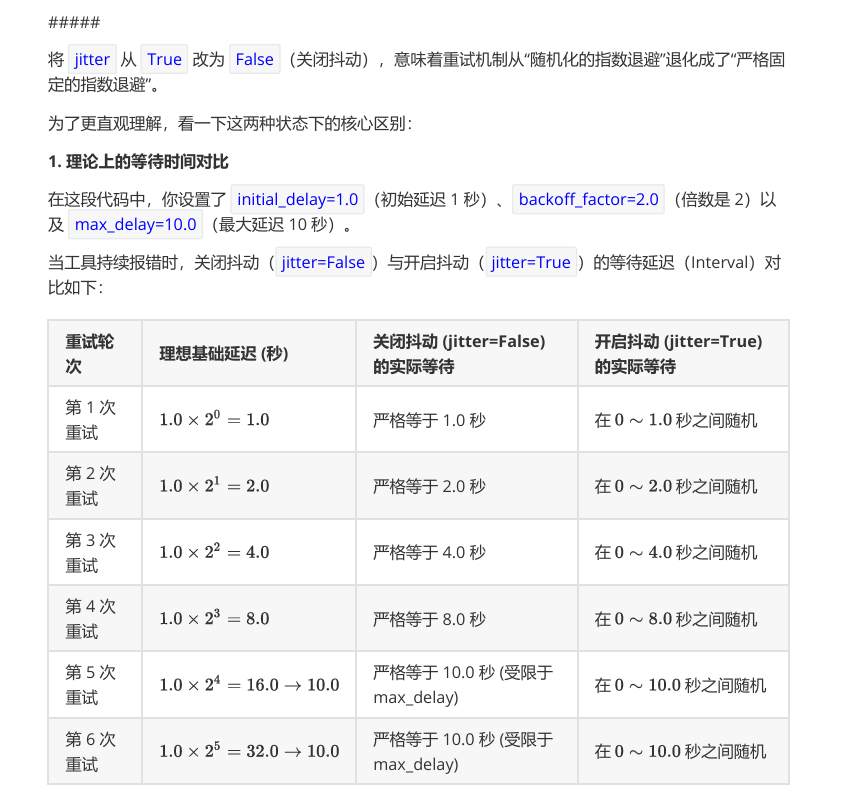

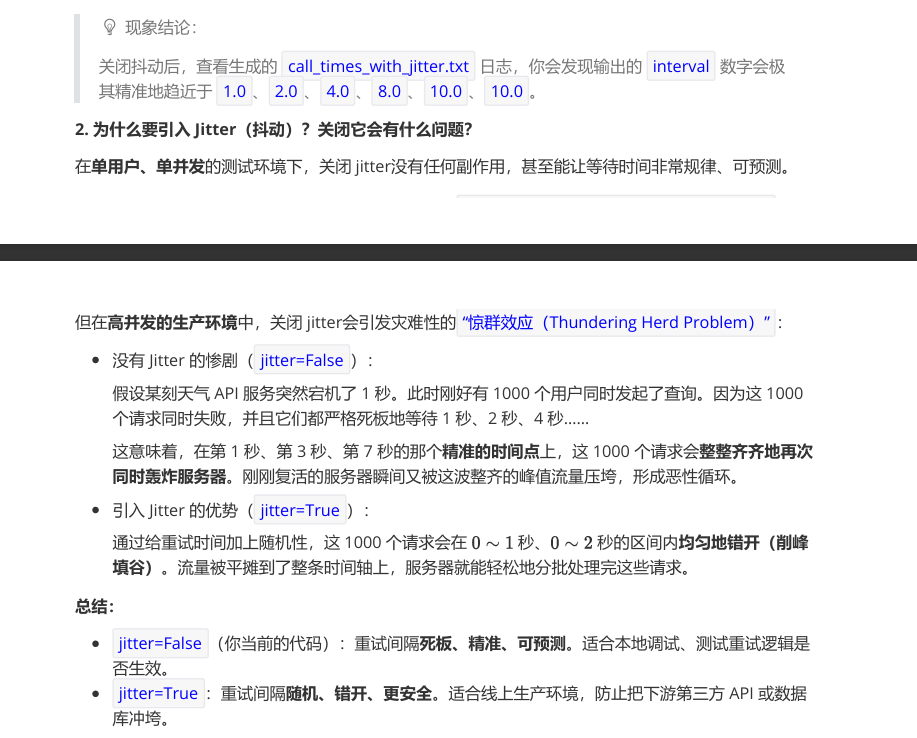

3.6 ModelRetryMiddleware中间件
模型调用失败时重试，策略和工具调用的重试一样，都是基于指数退避算法。
因此，本节案例不再重点观察指数退避算法，而是测试不同的退出模式。

举例1：继续运行

In [37]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelRetryMiddleware
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)

agent = create_agent(
    model="deepseek-cat",
    middleware=[
        ModelRetryMiddleware(
            max_retries=2,
            backoff_factor=2.0,
            initial_delay=1.0,
            max_delay=10.0,
            on_failure="continue",
            jitter=False,
        ),
    ],
)
response = agent.invoke({
    "messages": [HumanMessage("你好")]
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好
================================== Ai Message ==================================

Model call failed after 3 attempts with BadRequestError: Error code: 400 - {'error': {'message': 'The supported API model names are deepseek-v4-pro or deepseek-v4-flash, but you passed deepseek-cat.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


举例2：抛异常

In [38]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelRetryMiddleware
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)
agent = create_agent(
    model="deepseek-cat",
    middleware=[
        ModelRetryMiddleware(
            max_retries=2,
            backoff_factor=2.0,
            initial_delay=1.0,
            max_delay=10.0,
            on_failure="error",
            jitter=False,
        ),
    ],
)
response = agent.invoke({
    "messages": [HumanMessage("你好")]
})
for msg in response["messages"]:
    msg.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': 'The supported API model names are deepseek-v4-pro or deepseek-v4-flash, but you passed deepseek-cat.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}

 LLMToolEmulator中间件
 某些情况下，工具尚未开发完成，我们希望先测试工具调用，可以用LLM tool emulator模拟工具。

In [39]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolEmulator
from langchain.messages import HumanMessage


@tool
def get_weather(city: str):
    """查询指定城市天气"""
    return f"{city}今天天气晴朗"


agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        LLMToolEmulator(
            model=model,
        )
    ]
)
response = agent.invoke({
    "messages": [HumanMessage("今天北京天气如何")]
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

今天北京天气如何
================================== Ai Message ==================================

好的，我来查询一下北京今天的天气情况。
Tool Calls:
  get_weather (call_00_Ycy9fQ1x6bvV1QXRyehB8351)
 Call ID: call_00_Ycy9fQ1x6bvV1QXRyehB8351
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

{"city":"北京","weather":"晴","temperature":6,"humidity":25,"wind":"西北风3级","aqi":85,"update_time":"2025-04-08 14:00"}
================================== Ai Message ==================================

今天北京的天气情况如下：

- **天气状况**：☀️ 晴
- **气温**：6℃
- **湿度**：25%（比较干燥）
- **风力**：西北风3级
- **空气质量指数（AQI）**：85（良）
- **更新时间**：2025年4月8日 14:00

总体来看，今天北京天气晴朗，但气温偏低，空气也比较干燥，建议出门时注意保暖和补水哦！空气质量为良，适合户外活动。


3.8 ContextEditingMiddleware中间件
上下文编辑中间件，该中间件提供了上下文管理的一种方式。
通过更改发送给模型的消息列表来控制成本。
注意：不会更改消息列表。因此我们只能通过token用量来推测是否对消息列表进行了裁剪。

1. 实验组-启用上下文编辑

In [46]:
from langchain.agents import create_agent
from langchain.agents.middleware import ContextEditingMiddleware, ClearToolUsesEdit
from langchain.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

load_dotenv()
count = 0


@tool
def get_weather(city: str):
    """查询指定城市天气"""
    global count
    return (f"当前是第 {count} 次调用工具，{city}今天天气晴朗"
            f"天气非常好，北风，非常适合出行，盼望着，盼望着，"
            f"春天来了。我喜欢春天，你喜欢吗，天气真的很不错"
            f"万里无云，天气晴朗，春和景明，哈哈哈哈哈哈，这是凑字数的"
            f"真不错，天气非常好，适合出行，这里token挺多的"
            f"可以出门玩，尅有跑步，钓鱼，爬山，一切都很好哈哈哈")


agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        ContextEditingMiddleware(
            edits=[
                ClearToolUsesEdit(
                    trigger=20,
                    keep=0,
                ),
            ],
        ),
    ],
    checkpointer=InMemorySaver()
)
config = {"configurable": {"thread_id": "1"}}
for i in range(3):
    print("=" * 30, f"当前是第 {i + 1} 轮调用", "=" * 30)
    count = i + 1
    response = agent.invoke({
        "messages": [HumanMessage(f"第 {i + 1} 次询问：今天北京天气如何，一句话回答")]},
        config=config
    )
    print("---- 本次返回的 messages ----")
    for msg in response["messages"]:
        # msg.pretty_print()
        if isinstance(msg, AIMessage):
            if not msg.tool_calls:
                print(f"本次token用量：{msg.usage_metadata}")

============================== 当前是第 1 轮调用 ==============================
---- 本次返回的 messages ----
本次token用量：{'input_tokens': 352, 'output_tokens': 12, 'total_tokens': 364, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
============================== 当前是第 2 轮调用 ==============================
---- 本次返回的 messages ----
本次token用量：{'input_tokens': 352, 'output_tokens': 12, 'total_tokens': 364, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
本次token用量：{'input_tokens': 382, 'output_tokens': 12, 'total_tokens': 394, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
============================== 当前是第 3 轮调用 ==============================
---- 本次返回的 messages ----
本次token用量：{'input_tokens': 352, 'output_tokens': 12, 'total_tokens': 364, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
本次token用量：{'input_tokens': 382, 'output_tokens': 12, 'total_tokens': 394, 'input_token_details': {'cache_read': 256}, 'out

说明.
ContextEditingMiddleware 的价值：大模型多轮对话时，如果频繁调用产生大量文本的工具
（如代码执行、网页爬取），历史记录会急剧膨胀。这个中间件就像一个“上下文抽脂手术”，在不
影响当前对话的前提下，自动在后台删掉之前沉淀的工具调用废话，从而极大地节省 Token 费用
并防止超出模型最大上下文窗口（Context Window）。
2.
InMemorySaver ：它在内存中开辟了一个空间。第二轮和第三轮提问时，Agent 能通过
thread_id 自动找回前几轮的记忆。

2. 对照组-不裁剪上下文

In [47]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver

# 全局计数器，用于在工具内部追踪这是第几次被触发
count = 0


@tool
def get_weather(city: str):
    """查询指定城市天气"""
    global count
    # 故意返回一段非常冗长、包含大量 Token 的文本，用于测试中间件的 Token 清理/截断功能
    return (f"当前是第 {count} 次调用工具，{city}今天天气晴朗"
            f"天气非常好，北风，非常适合出行，盼望着，盼望着，"
            f"春天来了。我喜欢春天，你喜欢吗，天气真的很不错"
            f"万里无云，天气晴朗，春和景明，哈哈哈哈哈哈，这是凑字数的"
            f"真不错，天气非常好，适合出行，这里token挺多的"
            f"可以出门玩，尅有跑步，钓鱼，爬山，一切都很好哈哈哈")


agent = create_agent(
    model=model,
    tools=[get_weather],
    checkpointer=InMemorySaver()
)
config = {"configurable": {"thread_id": "1"}}
for i in range(3):
    print("=" * 30, f"当前是第 {i + 1} 轮调用", "=" * 30)
    count = i + 1
    response = agent.invoke({
        "messages": [HumanMessage(f"第 {i + 1} 次询问：今天北京天气如何，一句话回答")]},
        config=config
    )
    print("---- 本次返回的 messages ----")
    for msg in response["messages"]:
        # msg.pretty_print()
        if isinstance(msg, AIMessage):
            if not msg.tool_calls:
                print(f"本次token用量：{msg.usage_metadata}")

============================== 当前是第 1 轮调用 ==============================
---- 本次返回的 messages ----
本次token用量：{'input_tokens': 430, 'output_tokens': 8, 'total_tokens': 438, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
============================== 当前是第 2 轮调用 ==============================
---- 本次返回的 messages ----
本次token用量：{'input_tokens': 430, 'output_tokens': 8, 'total_tokens': 438, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
本次token用量：{'input_tokens': 456, 'output_tokens': 14, 'total_tokens': 470, 'input_token_details': {'cache_read': 384}, 'output_token_details': {}}
============================== 当前是第 3 轮调用 ==============================
---- 本次返回的 messages ----
本次token用量：{'input_tokens': 430, 'output_tokens': 8, 'total_tokens': 438, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
本次token用量：{'input_tokens': 456, 'output_tokens': 14, 'total_tokens': 470, 'input_token_details': {'cache_read': 384}, 'output

FilesystemFileSearchMiddleware中间件
基于系统的Glob和Grep检索工具，为Agent赋予本地文件搜索和分析的能力。
Glob根据文件路径检索
Grep根据文件内容检索

In [48]:
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware
from langchain.messages import HumanMessage

agent = create_agent(
    model=model,
    tools=[],  # 自动添加 Glob 和 Grep 工具
    middleware=[
        FilesystemFileSearchMiddleware(
            root_path="../todo_workspace",  #搜索目录
            # 【可选】限制搜索的文件后缀，防止模型读取非代码或无关文件
            # allowed_extensions=[".py", ".ipynb", ".js", ".md"],  # 允许的文件类型
            # 是否启用 ripgrep 搜索引擎：
            # 设为 True 可以获得比原生 Grep 更快的性能（前提是系统已安装 ripgrep）
            use_ripgrep=True,
            # 单个文件的最大读取限制（单位MB）：防止读取超大型日志或二进制文件导致 OOM
            max_file_size_mb=10
        ),
    ],
)
result = agent.invoke({
    "messages": [HumanMessage("找到包含add函数的Python或Jupyter文件")]
})
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

找到包含add函数的Python或Jupyter文件
================================== Ai Message ==================================

我来搜索包含 `add` 函数的 Python 或 Jupyter 文件。
Tool Calls:
  grep_search (call_00_ak2VPPtCzpQIfB4as5s25915)
 Call ID: call_00_ak2VPPtCzpQIfB4as5s25915
  Args:
    pattern: def add
    include: *.py
    output_mode: content
  grep_search (call_01_UpI5GtwHFElVRgTy4pFz3952)
 Call ID: call_01_UpI5GtwHFElVRgTy4pFz3952
  Args:
    pattern: def add
    include: *.ipynb
    output_mode: content
================================= Tool Message =================================
Name: grep_search

/my_add.py:1:def add(a: int, b: int) -> int:
================================= Tool Message =================================
Name: grep_search

No matches found
================================== Ai Message ==================================

找到了！在 `/my_add.py` 文件中包含 `add` 函数。

让我们看看这个文件的内容：
Tool Calls:
  grep_search (call_00

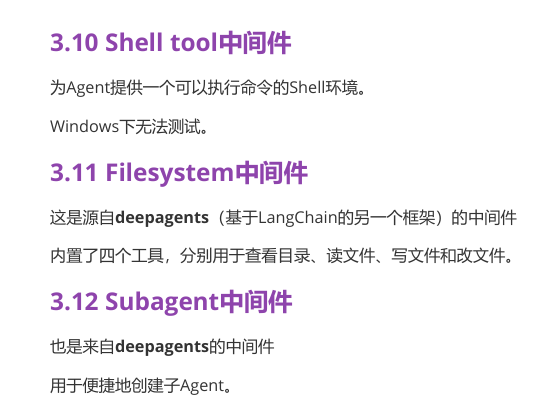